# Pneumonia Classification from Chest X-Rays Using a Quantum Spiking Neural Network

This notebook covers only the training and evaluation case for the **Alpha** neuron, implementing exponential decay. It presents the architecture, configuration, and experimental workflow used in this project, as well as the final metrics used to verify the validity of our results.


## 1. Imports and configuration

This block loads the necessary libraries, sets the seed to ensure the experiment is reproducible, and defines the layer sizes, number of time steps, epochs, and execution device.

In [1]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

SEED = 1524206349
batch_size = 200
num_inputs = 28 * 28
num_hidden = 1000
num_outputs = 2
num_steps = 25
num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Device: {device}")


Device: cpu


d:\PROYECTO QC neurociencia\codesq\Pneumonia mnist\Pneumonia_Mnist_QSNN\torch_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Alpha Neuron

The `AlphaSurrogate` class implements the neuron's forward pass and its derivative for backpropagation. The memory starts from the previous state, incorporates the contribution of the rotation associated with `theta`, and applies decay via the exponential factor `exp(-tau/T1)`. The `Alpha` class encapsulates this function and maintains the memory for each neuron.

In [5]:
class AlphaSurrogate(torch.autograd.Function):
    @staticmethod
    def forward(ctx, theta, tau, x, mem, threshold, T1):
        ctx.save_for_backward(theta, tau, x, mem)
        ctx.threshold = threshold
        ctx.T1 = T1
        gamma = 2 * torch.arcsin(torch.sqrt(mem * torch.exp(-tau / T1))) - 2 * torch.arcsin(torch.sqrt(mem))
        phi = torch.where(mem < threshold, 2 * torch.arcsin(torch.sqrt(mem)), 0.0)
        theta_term = torch.sin((theta + phi) * x / 2) ** 2
        gamma_term = torch.sin((gamma + phi) * (1 - x) / 2) ** 2
        mem = torch.where(mem < threshold, gamma_term + theta_term, 0.0)
        spike_out = torch.where(mem > threshold, 1.0, 0.0)
        mem = torch.where(mem > 1, 0.0, mem)
        return spike_out, mem

    @staticmethod
    def backward(ctx, grad_spike_out, grad_output):
        theta, tau, x, mem = ctx.saved_tensors
        T1 = ctx.T1
        grad_mem = 1 / (torch.pi * (1 + (torch.pi * mem).pow_(2))) * grad_output
        sqrt_mem_exp = torch.sqrt(mem * torch.exp(-tau / T1))
        sqrt_mem = torch.sqrt(mem)
        dtheta = x * torch.sin(x * (theta + 2 * torch.arcsin(sqrt_mem))) / 2
        dtau = -(x - 1) * sqrt_mem_exp * torch.sin(2 * (x - 1) * torch.arcsin(sqrt_mem_exp)) / (2 * T1 * torch.sqrt(1 - mem * torch.exp(-tau / T1)))
        return dtheta * grad_mem, dtau * grad_mem, grad_mem, None, None, None


class Alpha(nn.Module):
    def __init__(self, threshold=0.75, T1=60, N=1, device=torch.device("cpu")):
        super().__init__()
        self.N = N
        self.threshold = threshold
        self.T1 = T1
        self.device = device
        self.mem = torch.zeros(N, dtype=torch.float32, device=device)

    def forward(self, theta, tau, x):
        theta = theta.to(self.device)
        tau = tau.to(self.device)
        x = x.to(self.device)
        if self.mem.shape != theta.shape:
            self.mem = torch.zeros_like(theta)
        spike_out, self.mem = AlphaSurrogate.apply(theta, tau, x, self.mem, self.threshold, self.T1)
        return spike_out, self.mem

    def reset_mem(self, batch_size=None):
        if batch_size is None:
            self.mem = torch.zeros(self.N, dtype=torch.float32, device=self.device)
        else:
            self.mem = torch.zeros(batch_size, self.N, dtype=torch.float32, device=self.device)
        return self.mem


## 3. Loading and preparing PneumoniaMNIST

This block downloads the `.npz` file, creates a `Dataset` for training and testing, adds the channel dimension when the image is provided as a 2D array, and normalizes the pixel values ​​to the `[0, 1]` range. It also calculates weights to compensate for the class imbalance.

In [6]:
dataset_path = kagglehub.dataset_download("rijulshr/pneumoniamnist")
npz_path = os.path.join(dataset_path, "pneumoniamnist.npz")
data = np.load(npz_path)

class PneumoniaDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = torch.tensor(self.images[index], dtype=torch.float32)
        if image.ndim == 2:
            image = image.unsqueeze(0)
        if image.max() > 1:
            image = image / 255.0
        label = torch.tensor(int(np.asarray(self.labels[index]).squeeze()), dtype=torch.long)
        return image, label

train_dataset = PneumoniaDataset(data["train_images"], data["train_labels"])
test_dataset = PneumoniaDataset(data["test_images"], data["test_labels"])
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

class_counts = np.bincount(data["train_labels"].flatten())
weights = torch.tensor(len(data["train_labels"]) / (2 * class_counts), dtype=torch.float32, device=device)
print(f"Training: {len(train_dataset)} images")
print(f"Test: {len(test_dataset)} images")


Training: 3882 images
Test: 624 images


## 4. QSNN Architecture

The network uses two linear layers to obtain `theta` and `tau` at each layer. The first Alpha neuron transforms the input image, and the second produces two outputs—one per class. At each time step, the spike output and the memory of the second layer are stored. The memory is reset at the start of each batch to prevent information from one batch from propagating to the next.

In [9]:
class QSNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fcq1 = nn.Linear(num_inputs, num_hidden)
        self.fct1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = Alpha(N=num_hidden, device=device)
        self.fcq2 = nn.Linear(num_hidden, num_outputs)
        self.fct2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = Alpha(N=num_outputs, device=device)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        self.lif1.reset_mem()
        self.lif2.reset_mem()
        spk2_rec, mem2_rec = [], []

        for _ in range(num_steps):
            fcq1_out = self.fcq1(x)
            fct1_out = self.fct1(x)
            theta1 = torch.abs(fcq1_out) * torch.pi
            tau1 = torch.abs(fct1_out) * 200
            spk_in1 = torch.where(fcq1_out > 0, torch.ones_like(fcq1_out), torch.zeros_like(fcq1_out))
            spk1, _ = self.lif1(theta1, tau1, spk_in1)

            fcq2_out = self.fcq2(spk1)
            fct2_out = self.fct2(spk1)
            theta2 = torch.abs(fcq2_out) * torch.pi
            tau2 = torch.abs(fct2_out) * 200
            spk_in2 = torch.where(fcq2_out > 0, torch.ones_like(fcq2_out), torch.zeros_like(fcq2_out))
            spk2, mem2 = self.lif2(theta2, tau2, spk_in2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)


## 5. Training and evaluation

Weighted cross-entropy and Adam are used. The loss function is accumulated over the 25 time steps using the memory of the second layer. During evaluation, the predicted class is obtained by counting the spikes from each output over time and selecting the output with the highest count.

In [10]:
def train_and_evaluate(seed=SEED):
    set_seed(seed)
    train_generator = torch.Generator()
    train_generator.manual_seed(seed)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True, generator=train_generator)

    net = QSNN().to(device)
    loss_fn = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(net.parameters(), lr=5e-3, betas=(0.9, 0.999))
    history_loss = []
    start_time = time.time()

    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0
        for data_img, targets in train_loader:
            data_img, targets = data_img.to(device), targets.to(device)
            _, mem_rec = net(data_img)
            loss_val = torch.zeros(1, device=device)
            for step in range(num_steps):
                loss_val += loss_fn(mem_rec[step], targets)
            optimizer.zero_grad()
            loss_val.backward()
            optimizer.step()
            running_loss += loss_val.item()
        avg_loss = running_loss / len(train_loader)
        history_loss.append(avg_loss)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch{epoch + 1:02d}/{num_epochs} - Loss: {avg_loss:.4f}")

    train_time = time.time() - start_time
    net.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for data_img, targets in test_loader:
            data_img, targets = data_img.to(device), targets.to(device)
            spk_rec, _ = net(data_img)
            spike_count = spk_rec.sum(dim=0)
            _, pred = spike_count.max(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    return {
        "acc": accuracy_score(all_targets, all_preds),
        "prec": precision_score(all_targets, all_preds, average="weighted", zero_division=0),
        "rec": recall_score(all_targets, all_preds, average="weighted", zero_division=0),
        "f1": f1_score(all_targets, all_preds, average="weighted", zero_division=0),
        "conf": confusion_matrix(all_targets, all_preds),
        "history_loss": history_loss,
        "time": train_time,
    }

res = train_and_evaluate()


Epoch01/5 - Loss: 16.8117
Epoch05/5 - Loss: 15.4766


## 6. Experimental results

The execution of a neural network based on a modified neuron with exponential decay yielded an accuracy of 84.13% and a weighted F1 score of 0.8424. The resulting confusion matrix shows 193 and 382 correct predictions for Normal and Pneumonia, respectively.

In [12]:
import pandas as pd

results = pd.DataFrame({
    "Métrics": ["Accuracy", "Precision (weighted)", "Recall (weighted)", "F1-Score (weighted)"],
    "Value": [
        f"{res['acc'] * 100:.2f}%",
        f"{res['prec']:.4f}",
        f"{res['rec']:.4f}",
        f"{res['f1']:.4f}",
    ],
})
results


,Métrics,Value
0,Accuracy,84.13%
1,Precision (weighted),0.8446
2,Recall (weighted),0.8413
3,F1-Score (weighted),0.8424



## 7. Loss Evolution

The curve shows only the evolution of the Alpha model during the five epochs of the experiment. The value decreases from approximately 16.81 to 15.48.

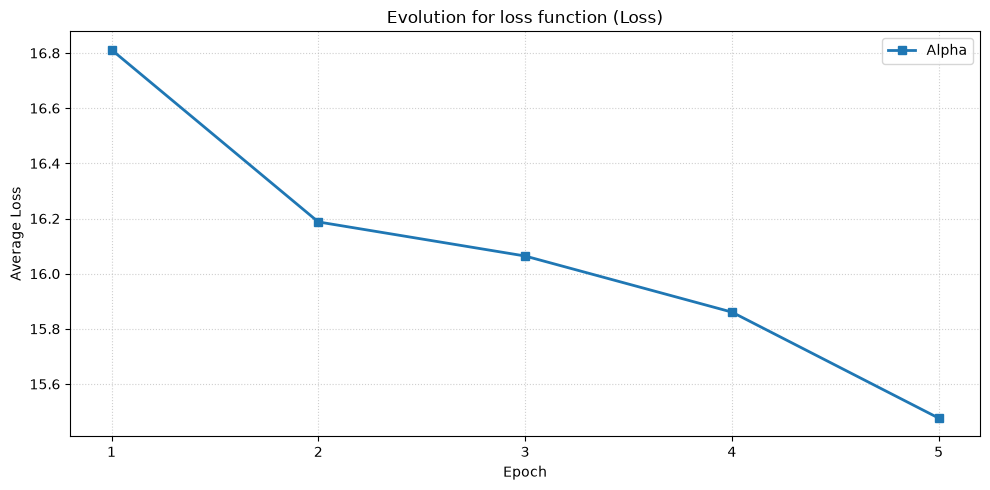

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), res["history_loss"], marker="s", linewidth=2, label="Alpha")
plt.title("Evolution for loss function (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.xticks(range(1, num_epochs + 1))
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


## 8. Confusion matrix

The matrix summarizes the model's predictions on the test set. The rows correspond to the actual class, and the columns to the predicted class.

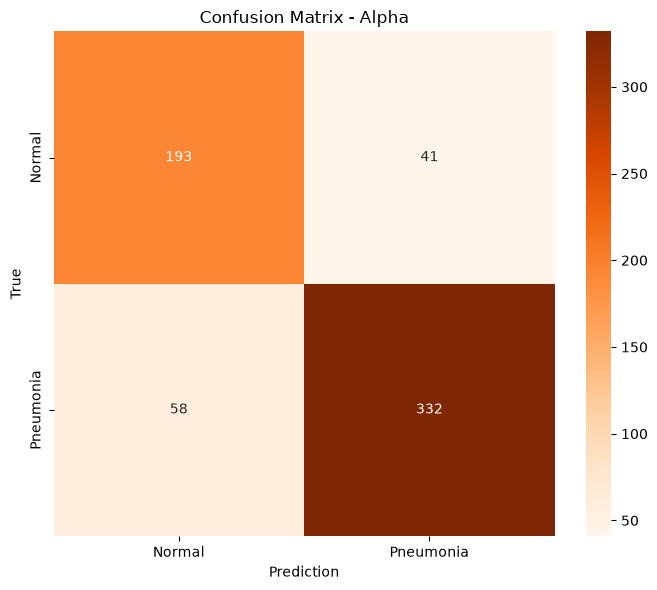

In [14]:
plt.figure(figsize=(7, 6))
sns.heatmap(res["conf"], annot=True, fmt="d", cmap="Oranges", xticklabels=["Normal", "Pneumonia"], yticklabels=["Normal", "Pneumonia"])
plt.title("Confusion Matrix - Alpha")
plt.xlabel("Prediction")
plt.ylabel("True")
plt.tight_layout()



## 9. Memory decay

With `x = 0`, the input contribution vanishes, and the memory dynamics are governed by the exponential term. For `mem(0)=0.70`, `tau=15`, and `T1=60`, the memory follows `mem(t)=0.70 exp(-15 t / 60)`.

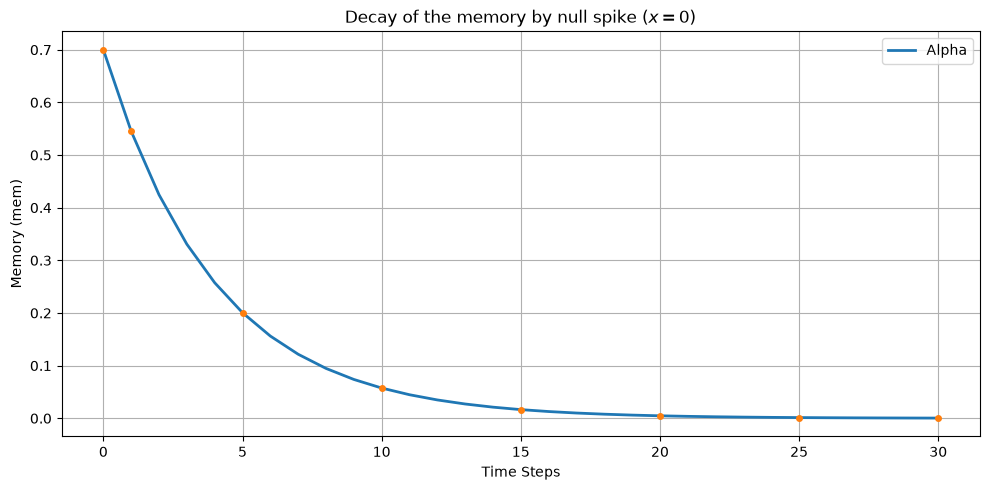

In [15]:
mem_init = 0.70
tau_val = 15.0
T1 = 60.0
t_steps = np.arange(31)
mem_decay = mem_init * np.exp(-tau_val * t_steps / T1)

plt.figure(figsize=(10, 5))
plt.plot(t_steps, mem_decay, linewidth=2, label="Alpha")
plt.plot(t_steps, mem_decay, "o", markevery=[0, 1, 5, 10, 15, 20, 25, 30], ms=4)
plt.title("Decay of the memory by null spike ($x=0$)")
plt.xlabel("Time Steps")
plt.ylabel("Memory (mem)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
